# BlackoutWatch — EAGLE-I EDA for Texas
Exploratory data analysis of power outage patterns across Texas counties (2014–2023).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/processed/eagle_i_texas_daily.csv', parse_dates=['date'])
print(f'Shape: {df.shape}')
print(f'Date range: {df.date.min()} to {df.date.max()}')
print(f'Counties: {df.fips_code.nunique()}')
print(f'\nOutage days: {df.outage_flag.sum():,} / {len(df):,} ({df.outage_flag.mean()*100:.2f}%)')
df.head()

Shape: (927608, 19)
Date range: 2014-01-01 00:00:00 to 2023-12-31 00:00:00
Counties: 254

Outage days: 497,256 / 927,608 (53.61%)


,fips_code,county,date,max_customers_out,sum_customers_out,outage_intervals,outage_hours,outage_flag,total_customers,year,coverage_min,coverage_max,coverage_available,growth_factor,total_customers_adj,outage_pct,month,day_of_week,day_of_year
0,48001,Anderson,2014-01-01,0,0,0,0.0,0,29000,2014,NaN,NaN,0,0.89,25810.0,0.0,1,2,1
1,48001,Anderson,2014-01-02,0,0,0,0.0,0,29000,2014,NaN,NaN,0,0.89,25810.0,0.0,1,3,2
2,48001,Anderson,2014-01-03,0,0,0,0.0,0,29000,2014,NaN,NaN,0,0.89,25810.0,0.0,1,4,3
3,48001,Anderson,2014-01-04,0,0,0,0.0,0,29000,2014,NaN,NaN,0,0.89,25810.0,0.0,1,5,4
4,48001,Anderson,2014-01-05,0,0,0,0.0,0,29000,2014,NaN,NaN,0,0.89,25810.0,0.0,1,6,5


## 1. County & Year-wise Outage Frequency

Significant outage days (>1% customers): 26,941 / 927,608 (2.90%)


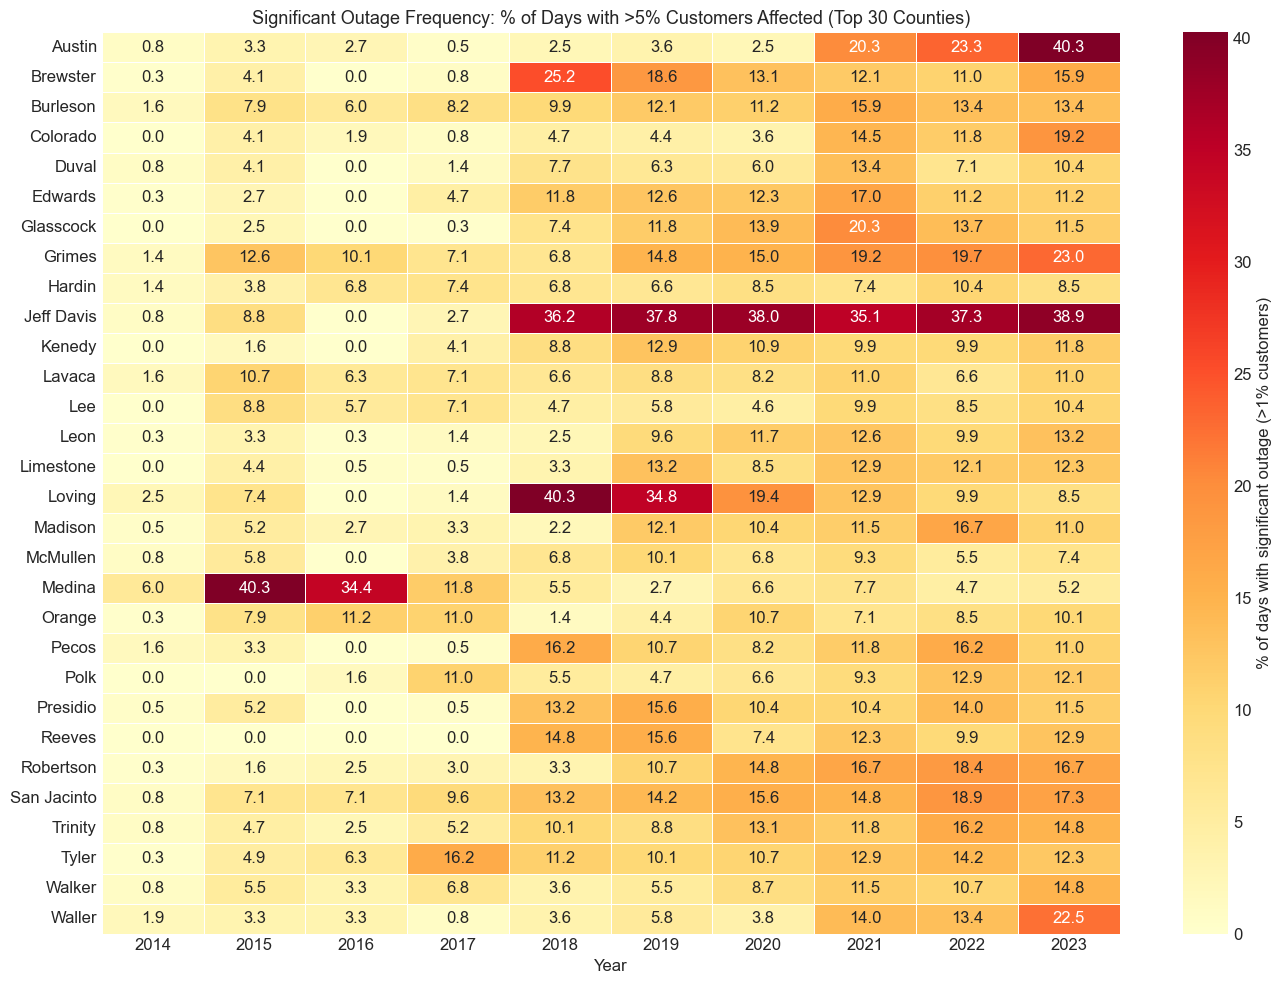

In [6]:
# Significant outage = more than 1% of county customers affected
df['significant_outage'] = (df['outage_pct'] > 0.05).astype(int)

print(f"Significant outage days (>1% customers): {df['significant_outage'].sum():,} / {len(df):,} ({df['significant_outage'].mean()*100:.2f}%)")

# Percentage of days with significant outages, per county per year
county_year = (
    df.groupby(['county', 'year'])['significant_outage']
    .mean()
    .reset_index()
    .rename(columns={'significant_outage': 'outage_pct_days'})
)
county_year['outage_pct_days'] *= 100

# Top 30 counties by significant outage frequency
top_counties = (
    df.groupby('county')['significant_outage'].mean()
    .nlargest(30)
    .index.tolist()
)

pivot = county_year[county_year['county'].isin(top_counties)].pivot(
    index='county', columns='year', values='outage_pct_days'
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot.fillna(0),
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% of days with significant outage (>1% customers)'}
)
ax.set_title('Significant Outage Frequency: % of Days with >5% Customers Affected (Top 30 Counties)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../reports/figures/01_county_year_outage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- **2014–2017 show low outage rates** — this is likely due to lower EAGLE-I coverage in early years rather than fewer actual outages. Coverage metadata is unavailable for these years.
- **2018+ shows more realistic patterns** — Texas coverage reached 80-93% from 2018 onward.
- **Jeff Davis, Loving, and Medina** are consistently high — these are small rural counties where even a minor line issue affects a large % of customers.
- **2021 spike across many counties** — aligns with Winter Storm Uri (Feb 2021), which caused widespread grid failure across Texas.
- **Threshold: >5% of county customers affected** — chosen to filter out routine minor outages (tree on a line, single transformer) and focus on events that meaningfully impact the grid.

## 2. Top Counties by Outage Frequency

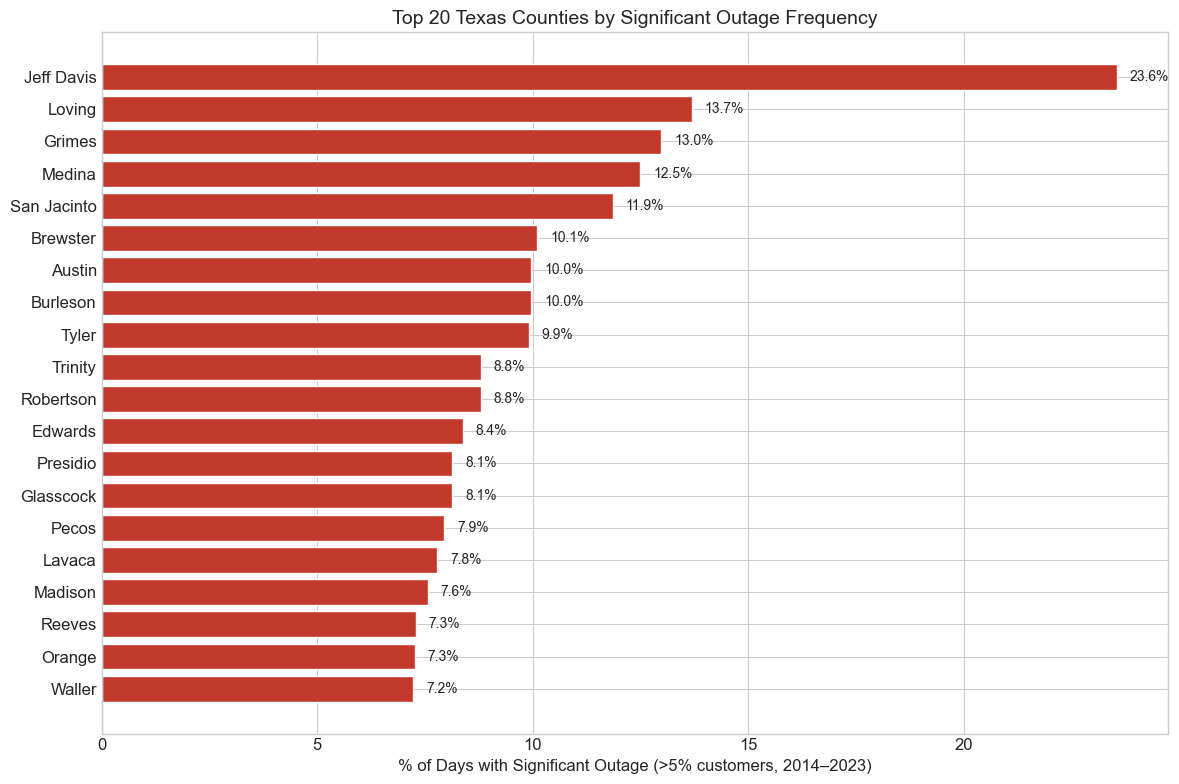


Top 20 counties:
     county  fips_code  significant_days  total_days  outage_pct  avg_max_customers
 Jeff Davis      48243               860        3652       23.55          51.729332
     Loving      48301               500        3652       13.69          22.701623
     Grimes      48185               474        3652       12.98         146.800619
     Medina      48325               456        3652       12.49         377.433902
San Jacinto      48407               433        3652       11.86         175.063524
   Brewster      48043               369        3652       10.10          79.302692
     Austin      48015               364        3652        9.97         316.712200
   Burleson      48051               364        3652        9.97          96.885694
      Tyler      48457               362        3652        9.91         137.427077
    Trinity      48455               321        3652        8.79         157.619472
  Robertson      48395               321        3652      

In [7]:
# Top 20 counties with most frequent significant outages (% of total days)
county_freq = (
    df.groupby(['fips_code', 'county'])
    .agg(
        significant_days=('significant_outage', 'sum'),
        total_days=('significant_outage', 'count'),
        avg_max_customers=('max_customers_out', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    )
    .reset_index()
)
county_freq['outage_pct'] = (county_freq['significant_days'] / county_freq['total_days'] * 100).round(2)
county_freq = county_freq.sort_values('outage_pct', ascending=False)

top20 = county_freq.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20['county'], top20['outage_pct'], color='#c0392b', edgecolor='white')
ax.set_xlabel('% of Days with Significant Outage (>5% customers, 2014–2023)')
ax.set_title('Top 20 Texas Counties by Significant Outage Frequency', fontsize=14)
ax.invert_yaxis()

for bar, val in zip(bars, top20['outage_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/02_top20_counties_significant_outage_freq.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 counties:')
print(top20[['county', 'fips_code', 'significant_days', 'total_days', 'outage_pct', 'avg_max_customers']].to_string(index=False))

### 2.1. Top Counties by Outage Frequency from 2018 onwards

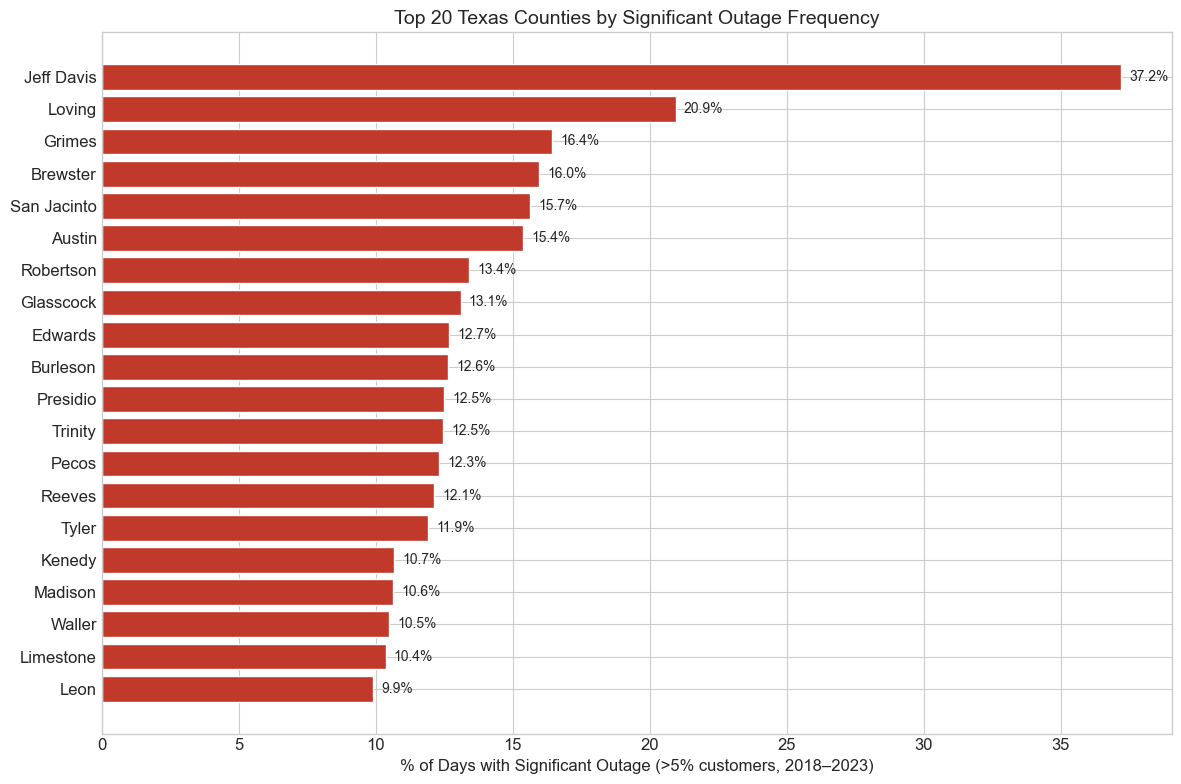


Top 20 counties:
     county  fips_code  significant_days  total_days  outage_pct  avg_max_customers
 Jeff Davis      48243               815        2191       37.20          48.704294
     Loving      48301               459        2191       20.95          23.493741
     Grimes      48185               360        2191       16.43         164.042680
   Brewster      48043               350        2191       15.97          78.126412
San Jacinto      48407               343        2191       15.65         188.854839
     Austin      48015               337        2191       15.38         432.135837
  Robertson      48395               294        2191       13.42         144.767429
  Glasscock      48173               287        2191       13.10          36.645527
    Edwards      48137               278        2191       12.69         104.160441
   Burleson      48051               277        2191       12.64         107.807988
   Presidio      48377               274        2191      

In [9]:
# Top 20 counties with most frequent significant outages (% of total days)
county_freq = (
    df[df['year'] >= 2018].groupby(['fips_code', 'county'])
    .agg(
        significant_days=('significant_outage', 'sum'),
        total_days=('significant_outage', 'count'),
        avg_max_customers=('max_customers_out', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    )
    .reset_index()
)
county_freq['outage_pct'] = (county_freq['significant_days'] / county_freq['total_days'] * 100).round(2)
county_freq = county_freq.sort_values('outage_pct', ascending=False)

top20 = county_freq.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20['county'], top20['outage_pct'], color='#c0392b', edgecolor='white')
ax.set_xlabel('% of Days with Significant Outage (>5% customers, 2018–2023)')
ax.set_title('Top 20 Texas Counties by Significant Outage Frequency', fontsize=14)
ax.invert_yaxis()

for bar, val in zip(bars, top20['outage_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/02_top20_counties_significant_outage_freq.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 counties:')
print(top20[['county', 'fips_code', 'significant_days', 'total_days', 'outage_pct', 'avg_max_customers']].to_string(index=False))

### Observations
- **Jeff Davis County dominates both views** — 23.5% (all years) and 37.2% (2018+). With only ~52 avg customers affected, this is a tiny rural county where small events register as significant.
- **Small rural counties are overrepresented** — Loving (~23 customers avg), Glasscock (~36), Kenedy (~38). In counties with very few total customers, even one downed line crosses the 5% threshold.
- **Outage rates roughly double in 2018–2023 vs 2014–2023** — this confirms that pre-2018 data had lower EAGLE-I coverage, diluting the percentages when included.
- **Waller and Austin counties are notable exceptions** — they have higher avg customers affected (430–557) suggesting these are genuinely impactful outages, not just small-county artifacts.
- **Implication for modeling:** We may want to filter out very small counties (e.g., <1,000 total customers) or use absolute customer thresholds alongside percentage-based ones to avoid the small-county bias.

## 3. Outage Duration Analysis (on outage days only)

Median outage-days per county per year: 231
Mean outage-days per county per year: 211

Outage Hours Statistics (across all county-days with outage):
  Median:          5.75 hrs
  Mean:            8.14 hrs
  75th percentile: 12.00 hrs
  90th percentile: 21.00 hrs
  Max:             24.00 hrs


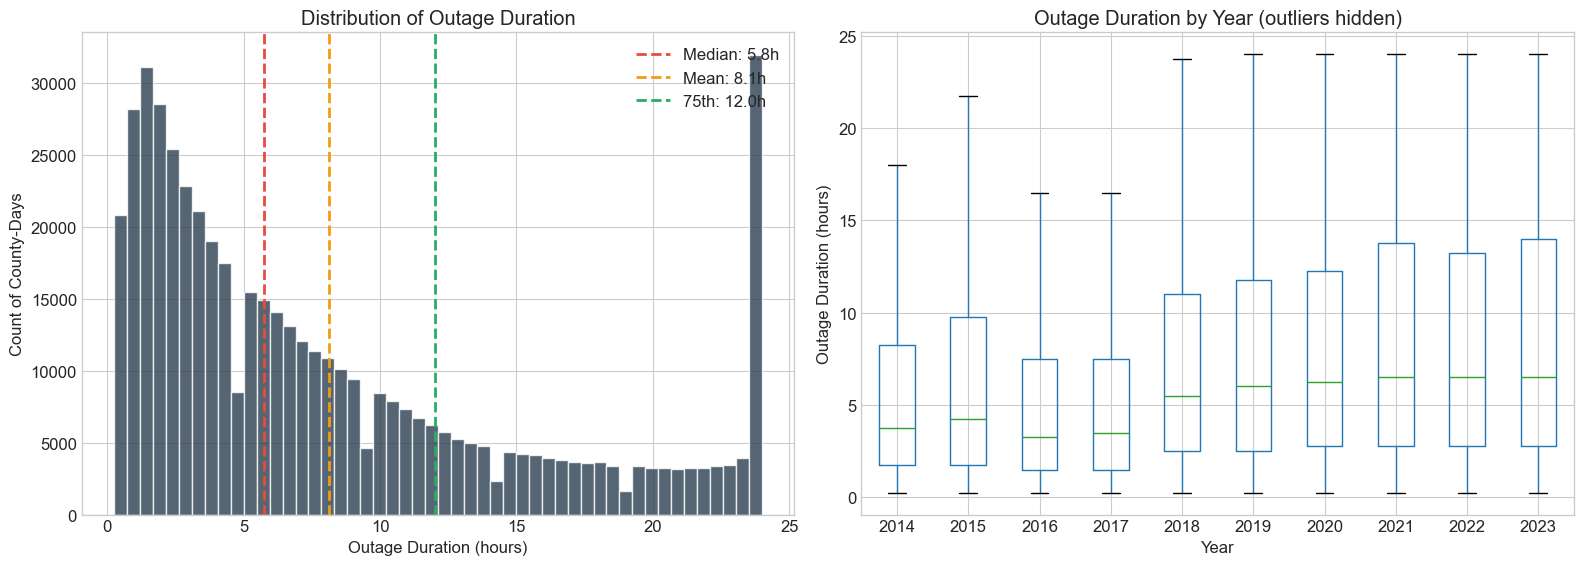

In [11]:
# Filter to only days with outages
outage_days = df[df['outage_flag'] == 1].copy()

# Median outage-days per county per year
county_year_outage = (
    outage_days.groupby(['county', 'year'])
    .size()
    .reset_index(name='outage_day_count')
)
median_outage_days = county_year_outage['outage_day_count'].median()
mean_outage_days = county_year_outage['outage_day_count'].mean()

print(f'Median outage-days per county per year: {median_outage_days:.0f}')
print(f'Mean outage-days per county per year: {mean_outage_days:.0f}')

print(f'\nOutage Hours Statistics (across all county-days with outage):')
print(f'  Median:          {outage_days["outage_hours"].median():.2f} hrs')
print(f'  Mean:            {outage_days["outage_hours"].mean():.2f} hrs')
print(f'  75th percentile: {outage_days["outage_hours"].quantile(0.75):.2f} hrs')
print(f'  90th percentile: {outage_days["outage_hours"].quantile(0.90):.2f} hrs')
print(f'  Max:             {outage_days["outage_hours"].max():.2f} hrs')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of outage hours
axes[0].hist(outage_days['outage_hours'], bins=50, color='#2c3e50', edgecolor='white', alpha=0.8)
axes[0].axvline(outage_days['outage_hours'].median(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Median: {outage_days["outage_hours"].median():.1f}h')
axes[0].axvline(outage_days['outage_hours'].mean(), color='#f39c12', linestyle='--', linewidth=2, label=f'Mean: {outage_days["outage_hours"].mean():.1f}h')
axes[0].axvline(outage_days['outage_hours'].quantile(0.75), color='#27ae60', linestyle='--', linewidth=2, label=f'75th: {outage_days["outage_hours"].quantile(0.75):.1f}h')
axes[0].set_xlabel('Outage Duration (hours)')
axes[0].set_ylabel('Count of County-Days')
axes[0].set_title('Distribution of Outage Duration')
axes[0].legend()

# Boxplot by year
outage_days.boxplot(column='outage_hours', by='year', ax=axes[1], showfliers=False)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Outage Duration (hours)')
axes[1].set_title('Outage Duration by Year (outliers hidden)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/figures/03_outage_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- **Most outages are short** — the distribution is heavily right-skewed with a median of 5.8 hours. The bulk of outages resolve within half a day.
- **The spike at 24 hours is notable** — this likely represents outages that lasted the entire day (all 96 intervals recorded), meaning the actual duration may have extended beyond 24h but our daily aggregation caps it there.
- **Outage durations have increased over time** — the boxplot shows median duration rising from ~4h (2014–2016) to ~7h (2020–2023). This could reflect either genuinely longer outages or improved EAGLE-I coverage capturing events that were previously missed.
- **2021 shows the widest spread** — consistent with Winter Storm Uri causing multi-day outages across Texas, pushing durations to the 24h cap for many counties.
- **Median outage-days per county per year: 136, Mean: 195** — the average Texas county experiences some level of outage on more than half the days in a year, reinforcing why the >5% significance threshold is necessary.

## 4. Coverage-Adjusted Impact Analysis (2018–2022)

Coverage-adjusted analysis (2018–2022):
  Total county-days: 463,804
  Outage county-days: 339,892 (73.28%)

Yearly Summary:
 year  pct_days_with_outage  avg_outage_pct_on_outage_days  median_outage_pct_on_outage_days  max_outage_pct  coverage_min  coverage_max
 2018             68.156617                       2.062514                          0.099458     5092.857143          81.0          90.0
 2019             73.097832                       1.955159                          0.106809     3653.488372          59.0          93.0
 2020             75.762661                       1.988843                          0.102058     5155.813953          61.0          63.0
 2021             75.083594                       2.890986                          0.123874     3379.545455          82.0          94.0
 2022             74.310215                       2.159476                          0.120610     5152.272727          85.0          93.0


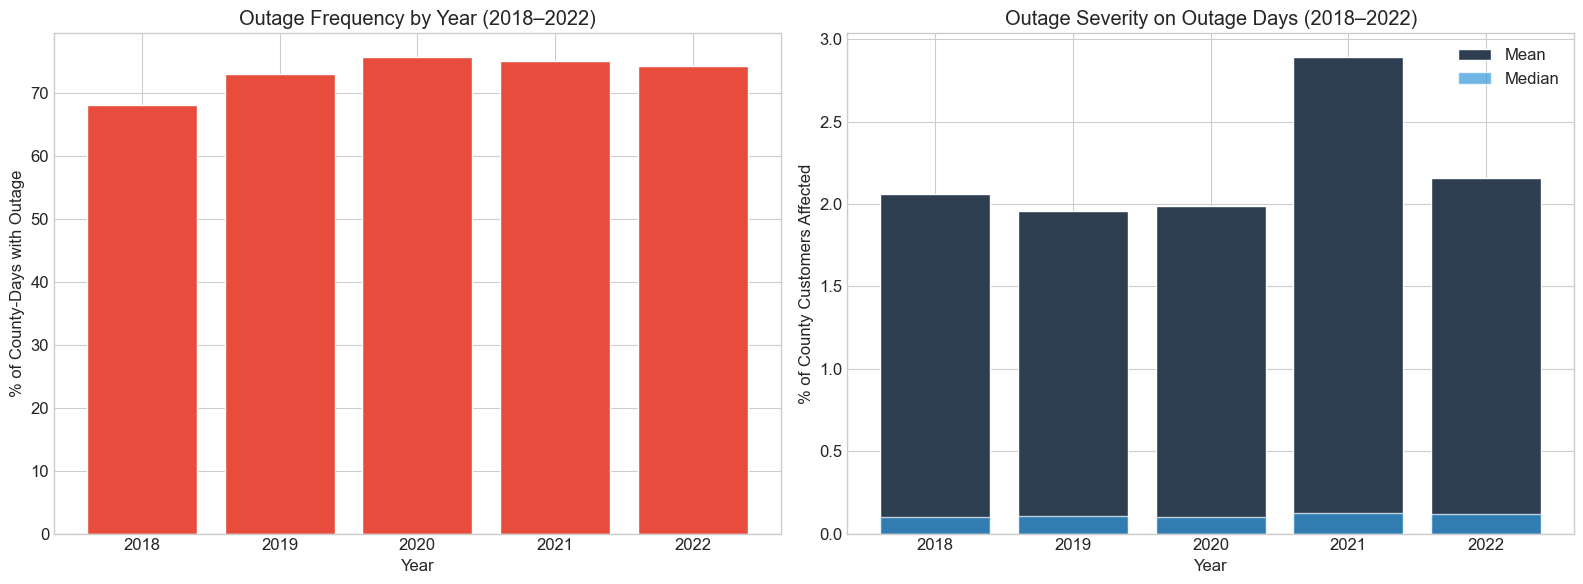

In [13]:
# Focus on years with coverage data
covered = df[df['coverage_available'] == 1].copy()
covered_outages = covered[covered['outage_flag'] == 1]

print('Coverage-adjusted analysis (2018–2022):')
print(f'  Total county-days: {len(covered):,}')
print(f'  Outage county-days: {len(covered_outages):,} ({len(covered_outages)/len(covered)*100:.2f}%)')

# Yearly summary
yearly = covered.groupby('year').agg(
    pct_days_with_outage=('outage_flag', 'mean'),
    avg_outage_pct_on_outage_days=('outage_pct', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    median_outage_pct_on_outage_days=('outage_pct', lambda x: x[x > 0].median() if (x > 0).any() else 0),
    max_outage_pct=('outage_pct', 'max'),
    coverage_min=('coverage_min', 'first'),
    coverage_max=('coverage_max', 'first'),
).reset_index()

yearly['pct_days_with_outage'] *= 100
yearly['avg_outage_pct_on_outage_days'] *= 100
yearly['median_outage_pct_on_outage_days'] *= 100
yearly['max_outage_pct'] *= 100
yearly['coverage_min'] *= 100
yearly['coverage_max'] *= 100

print('\nYearly Summary:')
print(yearly.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# % of county-days with outage by year
axes[0].bar(yearly['year'], yearly['pct_days_with_outage'], color='#e74c3c', edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('% of County-Days with Outage')
axes[0].set_title('Outage Frequency by Year (2018–2022)')

# Average outage severity on outage days
axes[1].bar(yearly['year'], yearly['avg_outage_pct_on_outage_days'], color='#2c3e50', edgecolor='white', label='Mean')
axes[1].bar(yearly['year'], yearly['median_outage_pct_on_outage_days'], color='#3498db', edgecolor='white', alpha=0.7, label='Median')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of County Customers Affected')
axes[1].set_title('Outage Severity on Outage Days (2018–2022)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/04_coverage_adjusted_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Max vs Total Customers Affected — Outage Shape Analysis

Impact Ratio (sum / max) — higher means longer-lasting outage:
  Median: 9.0
  Mean:   12.2
  Min:    1.0 (quick spike)
  Max:    96.0 (sustained all day)


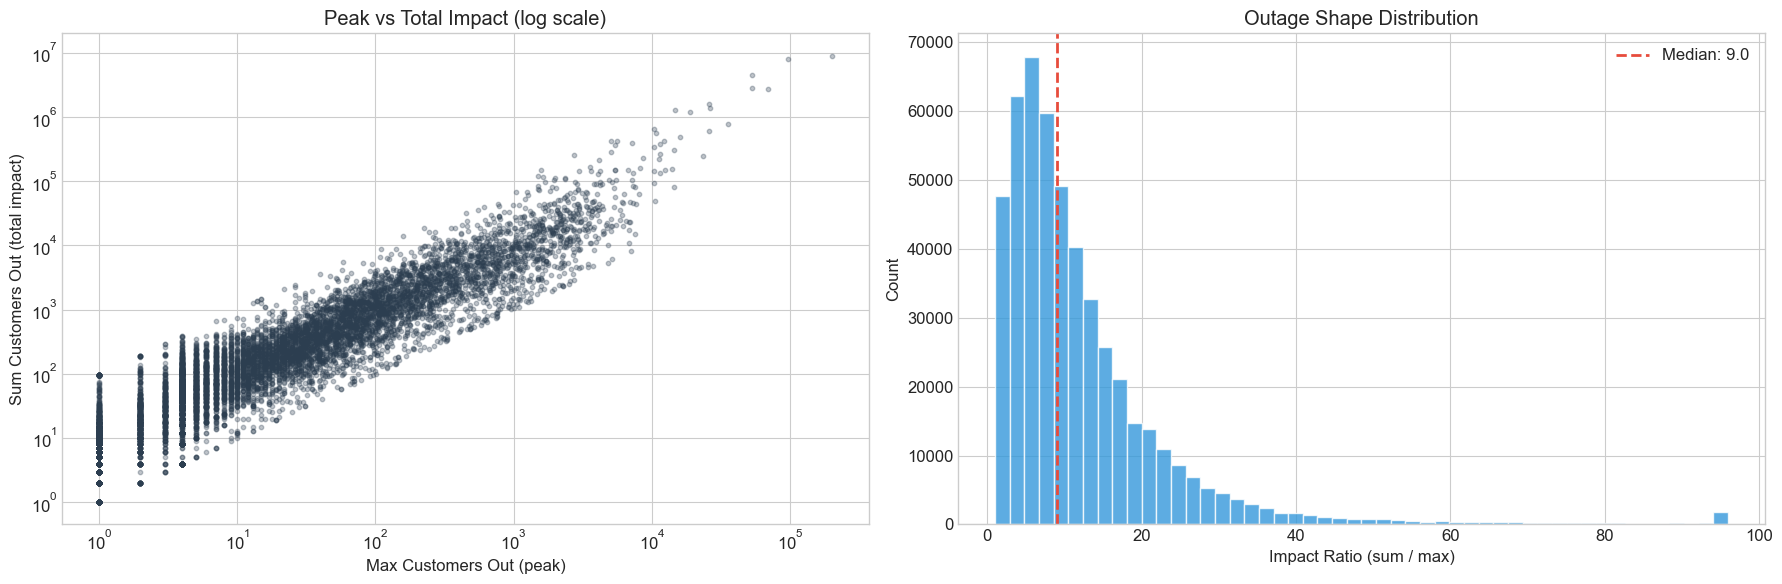

In [18]:
outage_days = df[df['outage_flag'] == 1].copy()

# Ratio: sum / max — higher = longer sustained outage, lower = quick spike
outage_days['impact_ratio'] = outage_days['sum_customers_out'] / outage_days['max_customers_out'].replace(0, np.nan)

print('Impact Ratio (sum / max) — higher means longer-lasting outage:')
print(f'  Median: {outage_days["impact_ratio"].median():.1f}')
print(f'  Mean:   {outage_days["impact_ratio"].mean():.1f}')
print(f'  Min:    {outage_days["impact_ratio"].min():.1f} (quick spike)')
print(f'  Max:    {outage_days["impact_ratio"].max():.1f} (sustained all day)')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter: max vs sum (log scale)
sample = outage_days.sample(min(10000, len(outage_days)), random_state=42)
axes[0].scatter(sample['max_customers_out'], sample['sum_customers_out'], alpha=0.3, s=10, color='#2c3e50')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Max Customers Out (peak)')
axes[0].set_ylabel('Sum Customers Out (total impact)')
axes[0].set_title('Peak vs Total Impact (log scale)')

# Distribution of impact ratio
axes[1].hist(outage_days['impact_ratio'].clip(upper=96), bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(outage_days['impact_ratio'].median(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Median: {outage_days["impact_ratio"].median():.1f}')
axes[1].set_xlabel('Impact Ratio (sum / max)')
axes[1].set_ylabel('Count')
axes[1].set_title('Outage Shape Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/05_max_vs_total_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Seasonal Patterns

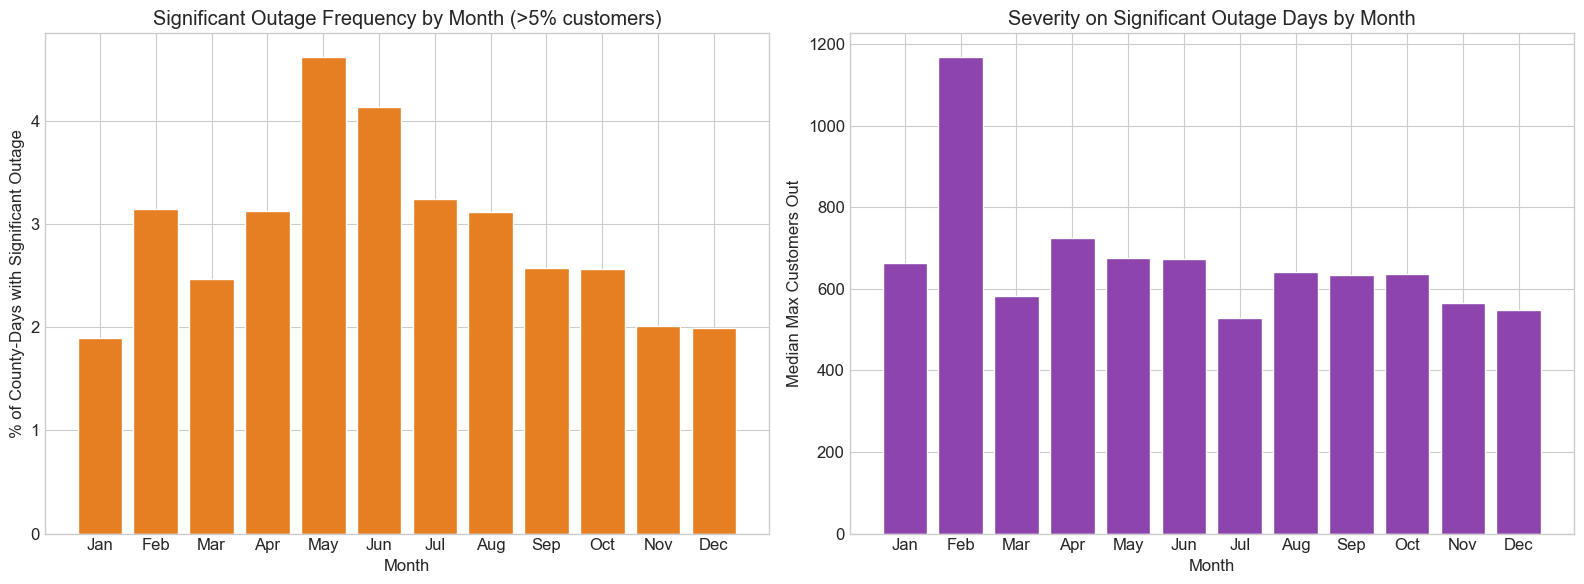

In [20]:
# Monthly significant outage frequency
monthly = df.groupby('month')['significant_outage'].mean().reset_index()
monthly['outage_pct'] = monthly['significant_outage'] * 100
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(monthly['month'], monthly['outage_pct'], color='#e67e22', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_labels)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('% of County-Days with Significant Outage')
axes[0].set_title('Significant Outage Frequency by Month (>5% customers)')

# Monthly severity on significant outage days only
monthly_severity = (
    df[df['significant_outage'] == 1]
    .groupby('month')['max_customers_out']
    .median()
    .reset_index()
)

axes[1].bar(monthly_severity['month'], monthly_severity['max_customers_out'], color='#8e44ad', edgecolor='white')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_labels)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Median Max Customers Out')
axes[1].set_title('Severity on Significant Outage Days by Month')

plt.tight_layout()
plt.savefig('../reports/figures/06_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- **May–July is peak outage season** — May leads at ~4.6%, likely driven by severe thunderstorms, tornadoes, and the start of hurricane season in Texas.
- **January is least frequent but most severe** — only ~1.9% of county-days have significant outages, but when they happen, median peak customers out (~1,175) is nearly double any other month. This is the Winter Storm Uri effect.
- **Frequency and severity tell different stories** — summer months have more outages but they tend to affect fewer customers per event. Winter outages are rarer but hit harder.
- **Implication for modeling:** Seasonal features (month, season) will be important predictors. The model needs to capture that winter = low frequency but high severity, summer = high frequency but moderate severity.

## 7. Quick Summary Stats

In [21]:
print('=== BlackoutWatch EAGLE-I EDA Summary ===')
print(f'\nDataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Counties: {df.fips_code.nunique()}')
print(f'Date range: {df.date.min().date()} to {df.date.max().date()}')
print(f'\nClass balance:')
print(f'  No outage: {(df.outage_flag == 0).sum():,} ({(df.outage_flag == 0).mean()*100:.2f}%)')
print(f'  Outage:    {(df.outage_flag == 1).sum():,} ({(df.outage_flag == 1).mean()*100:.2f}%)')
print(f'\n→ Heavy class imbalance — will need SMOTE or class weights in classification')
print(f'\nOn outage days:')
outage = df[df.outage_flag == 1]
print(f'  Max customers out — median: {outage.max_customers_out.median():.0f}, mean: {outage.max_customers_out.mean():.0f}')
print(f'  Outage hours — median: {outage.outage_hours.median():.1f}, mean: {outage.outage_hours.mean():.1f}')
print(f'  Outage % — median: {outage.outage_pct.median()*100:.3f}%, mean: {outage.outage_pct.mean()*100:.3f}%')

=== BlackoutWatch EAGLE-I EDA Summary ===

Dataset: 927,608 rows × 20 columns
Counties: 254
Date range: 2014-01-01 to 2023-12-31

Class balance:
  No outage: 430,352 (46.39%)
  Outage:    497,256 (53.61%)

→ Heavy class imbalance — will need SMOTE or class weights in classification

On outage days:
  Max customers out — median: 11, mean: 279
  Outage hours — median: 5.8, mean: 8.1
  Outage % — median: 0.102%, mean: 2.121%
